# Simple PM++ example

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from matplotlib import pyplot as plt
import os

os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["TF_GPU_ALLOCATOR"] = "cuda_malloc_async"
# os.environ["JAX_TRACEBACK_FILTERING"] = "off"

import jax
import jax.numpy as jnp
from jax.sharding import NamedSharding, PartitionSpec as P


In [3]:
try:
    os.chdir("/home/r/rouzib/links/scratch/pm")
    local = False
except:
    local = True

print(local)

True


In [4]:
pip freeze | grep jax

jax==0.6.2
jax-cosmo==0.1.0
jax-cuda12-pjrt==0.6.2
jax-cuda12-plugin==0.6.2
jaxdecomp==0.3.0
jaxlib==0.6.2
jaxpm==0.1.6
jaxtyping==0.2.34
Note: you may need to restart the kernel to use updated packages.


In [5]:
from pmwd import (
    white_noise as white_noise_pmwd,
    linear_modes as linear_modes_pmwd,
    boltzmann,
    lpt as lpt_pmwd,
    Particles as ParticlesPMWD,
)
from pmwd import nbody as nbody_pmwd, scatter as scatter_pmwd, Configuration as ConfigurationPMWD

from pmpp.configuration import Configuration
from pmpp.multigpu_configuration import MultiGPUConfiguration
from pmpp.cosmo import SimpleLCDM
from pmpp.scatter import scatter
from pmpp.lpt import lpt
from pmpp.nbody import nbody
from pmpp.particles import Particles
from pmpp.utils import create_compute_mesh
from pmpp.modes import linear_modes, white_noise
from pmpp.utils import AXIS_NAME


In [6]:
box_size = 100
seed = 0

In [7]:
def init_sim(num_ptcl, mesh_shape):
    with jax.default_device(jax.devices("cpu")[0]):
        ptcl_grid_shape = (num_ptcl,) * 3
        ptcl_spacing = box_size / ptcl_grid_shape[0]
        conf = ConfigurationPMWD(ptcl_spacing, ptcl_grid_shape, mesh_shape=mesh_shape)
        cosmo = SimpleLCDM(conf)
        cosmo = boltzmann(cosmo, conf)

        modes = white_noise_pmwd(seed, conf)
        modes = linear_modes_pmwd(modes, cosmo, conf)
        ptcl_lpt, _ = lpt_pmwd(modes, cosmo, conf)

    ptcl_lpt = jax.device_put(ptcl_lpt, jax.devices()[0])
    cosmo = jax.device_put(cosmo, jax.devices()[0])
    return ptcl_lpt, conf, cosmo

In [8]:
ptcl_lpt, conf, cosmo = init_sim(128, 1)
nbody_pmwd = jax.jit(nbody_pmwd, static_argnames=("conf", "reverse"))
ptcl_final, _ = nbody_pmwd(ptcl_lpt, None, cosmo, conf)

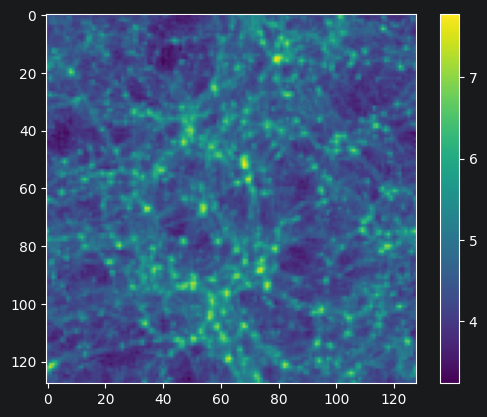

In [9]:
dens = scatter_pmwd(ptcl_final, conf)
plt.imshow(jnp.log(dens.sum(1)))
plt.colorbar()

In [10]:
%timeit -r 2 -n 2 jax.block_until_ready(nbody_pmwd(ptcl_lpt, None, cosmo, conf))

248 ms ± 11 ms per loop (mean ± std. dev. of 2 runs, 2 loops each)


In [11]:
!nvidia-smi

Mon Apr 13 23:58:27 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 590.57                 Driver Version: 591.86         CUDA Version: 13.1     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3090        On  |   00000000:0E:00.0  On |                  N/A |
| 60%   77C    P2            297W /  350W |    2226MiB /  24576MiB |      9%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

/usr/lib/python3.10/pty.py:89: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()


# mGPU full sim

In [12]:
def init_mgpu(num_ptcl, mesh_shape, num_devices=None, max_ptcl_per_slice=1.2, max_share_ptcl=20_000,
              max_share_gather_ptcl=50_000):
    ptcl_grid_shape = (num_ptcl,) * 3
    ptcl_spacing = box_size / ptcl_grid_shape[0]

    gpu_devices = [device for device in jax.devices() if device.platform == "gpu"]
    if len(gpu_devices) < 2:
        raise RuntimeError("This PM++ multi-GPU example requires at least 2 GPUs.")
    if num_devices is None:
        selected_devices = gpu_devices
    else:
        selected_devices = gpu_devices[:min(num_devices, len(gpu_devices))]
    num_devices = len(selected_devices)

    compute_mesh = create_compute_mesh(selected_devices)
    conf_mGPU = Configuration(
        ptcl_spacing,
        ptcl_grid_shape,
        mesh_shape=mesh_shape,
        multigpu=MultiGPUConfiguration(compute_mesh=compute_mesh, mode="mesh_halo"),
        max_ptcl_per_slice=int(num_ptcl * num_ptcl * num_ptcl / num_devices * max_ptcl_per_slice),
        max_share_ptcl=max_share_ptcl,
        max_halo_share_ptcl=max_share_ptcl,
        max_share_gather_ptcl=max_share_gather_ptcl,
    )

    cosmo = SimpleLCDM(conf_mGPU)
    cosmo = boltzmann(cosmo, conf_mGPU)
    modes = white_noise(seed, conf_mGPU)
    modes = linear_modes(modes, cosmo, conf_mGPU)
    ptcl_lpt_mGPU = lpt(modes, cosmo, conf_mGPU)

    return ptcl_lpt_mGPU, conf_mGPU, cosmo


In [13]:
# 64, 1, 4: 1.2, 500, 8000
# 64, 5, 4: 1.2, 500, 3000
# 128, 1, 4: 1.2, 2000, 25000
# 128, 5, 4: 1.2, 2000, 10000
# 256, 1, 4: 1.2, 20000, 90000
# 256, 3, 4: 1.2, 20000, 50000
# 256, 5, 4: 1.2, 20000, 30000
# 512, 1, 4: 1.3, 100000, 400000
# 512, 2, 4: 1.3, 105000, 200000

In [14]:
nbody_jitted_mGPU = jax.jit(nbody, static_argnames=("conf", "reverse"))

In [15]:
ptcl_lpt_mGPU, conf_mGPU, cosmo = init_mgpu(128, 1, num_devices=2, max_ptcl_per_slice=1.25, max_share_ptcl=11000,
                                            max_share_gather_ptcl=30000)
ptcl_final_mGPU = nbody_jitted_mGPU(ptcl_lpt_mGPU, cosmo, conf_mGPU)

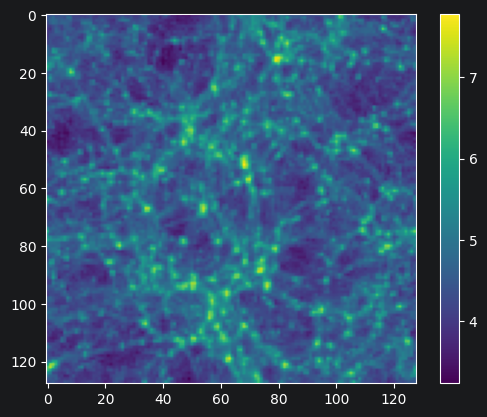

In [16]:
dens_mGPU = scatter(ptcl_final_mGPU, conf_mGPU)
plt.imshow(jnp.log(dens_mGPU.sum(1)))
plt.colorbar()

In [17]:
%timeit -r 2 -n 2 jax.block_until_ready(nbody_jitted_mGPU(ptcl_lpt_mGPU, cosmo, conf_mGPU))

866 ms ± 50.7 ms per loop (mean ± std. dev. of 2 runs, 2 loops each)


In [18]:
!nvidia-smi

Mon Apr 13 23:59:05 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 590.57                 Driver Version: 591.86         CUDA Version: 13.1     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3090        On  |   00000000:0E:00.0  On |                  N/A |
| 62%   76C    P2            224W /  350W |    2356MiB /  24576MiB |     12%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [19]:
print(dens_mGPU.addressable_data(index=0).shape)

(64, 128, 128)


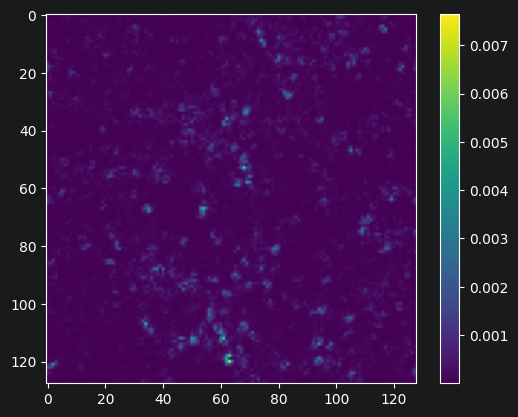

In [20]:
plt.imshow(jnp.abs(((dens - jax.device_get(dens_mGPU))).sum(1)))
plt.colorbar()